## Exploratory Data Analysis

In this part we look at the correlations between the variables and apply a PCA to the inputs, to develop an intuition on the data before the modelling. Everything is computed on `train.csv` only, the test set stays closed until the final evaluation.

### Main observations

- **Strength against ductility:** `yield_strength_MPa` and `uts_MPa` carry almost the same information (0.92), and both go against `elongation_pct` (-0.69 and -0.74). A stronger weld is less ductile, so a good weld is a compromise, not the maximum of every target.
- **Alloying elements:** Cr, Mo, V, N_ppm and Nb_ppm are the inputs most linked to the tensile targets (correlation from 0.28 to 0.51 in absolute value). They raise the strength and lower the elongation.
- **Charpy:** `charpy_toughness_J` has no correlation above 0.23 with any input. Its strongest link is `charpy_temp_C` (0.47), which is why the test temperature is an input of the Charpy model.
- **Redundant inputs:** Current, voltage, heat input and the welding process carry the same information (up to 0.89 in absolute value). Some strong Pearson correlations (S-P, Cr-N_ppm) only come from a few rows, Spearman is much lower.
- **PCA:** The first two components explain 32% of the variance, and 12 components are needed for 80%. The first plane still separates the MMA C-Mn welds, the submerged arc welds (high heat input) and the Cr-Mo welds (alloyed and heat treated), which matches the alloy families of `definition_bonne_soudure.md`.

### Operations in order

1. Load `../data/train.csv`, the output of the split notebook.
2. List the inputs and the targets, and add the alloy family of each row.
3. Plot the correlation matrix of the inputs, and list the most correlated pairs with Pearson and Spearman.
4. Print the correlations between the targets, with the number of rows behind each one.
5. Plot the correlations between the inputs and the targets.
6. Compare the standard deviations of the inputs, to justify the standardisation.
7. Fit a PCA on the standardised inputs and plot the explained variance.
8. Print the correlations between the inputs and the first four components, with the targets as supplementary variables.
9. Plot the correlation circles of the first four components.
10. Plot the rows on the first plane, coloured by alloy family and by welding process.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
df = pd.read_csv("../data/train.csv")

chem_cols = ["C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "O_ppm", "Ti_ppm", "N_ppm", "Al_ppm", "Nb_ppm"]
process_cols = ["current_A", "voltage_V", "AC_DC", "electrode_polarity", "AC_DC_unknown", "heat_input_kJ_mm", "interpass_temp_C", "pwht_temp_C", "pwht_time_h"]
process_cols += [c for c in df.columns if c.startswith("weld_type_")]
input_cols = chem_cols + process_cols
target_cols = ["yield_strength_MPa", "uts_MPa", "elongation_pct", "charpy_toughness_J"]

df["family"] = "C-Mn"
df.loc[df["Cr"].between(1.9, 2.7) & df["Mo"].between(0.85, 1.35), "family"] = "CrMo2"
df.loc[df["Cr"].between(8, 10.5) & (df["V"] >= 0.15), "family"] = "CrMo91"
df.loc[df["Cr"].between(8, 10.5) & (df["V"] < 0.15), "family"] = "CrMo9"

print(df.shape, len(input_cols))
df["family"].value_counts()

(1229, 39) 30


family
C-Mn      1037
CrMo2      135
CrMo91      56
CrMo9        1
Name: count, dtype: int64

- **Inputs:** The 30 columns known before welding: chemistry, welding parameters, post-weld heat treatment and the one-hot welding process.
- **Targets:** The 4 properties of `definition_bonne_soudure.md`. `charpy_temp_C` is the temperature of the Charpy test, an input of the Charpy model only. `reduction_area_pct` is not a target, `weld_id` and `weld_group` are identifiers.
- **family:** Computed from Cr, Mo and V with the rules of `definition_bonne_soudure.md`. It is only used to read the results, it is not an input.

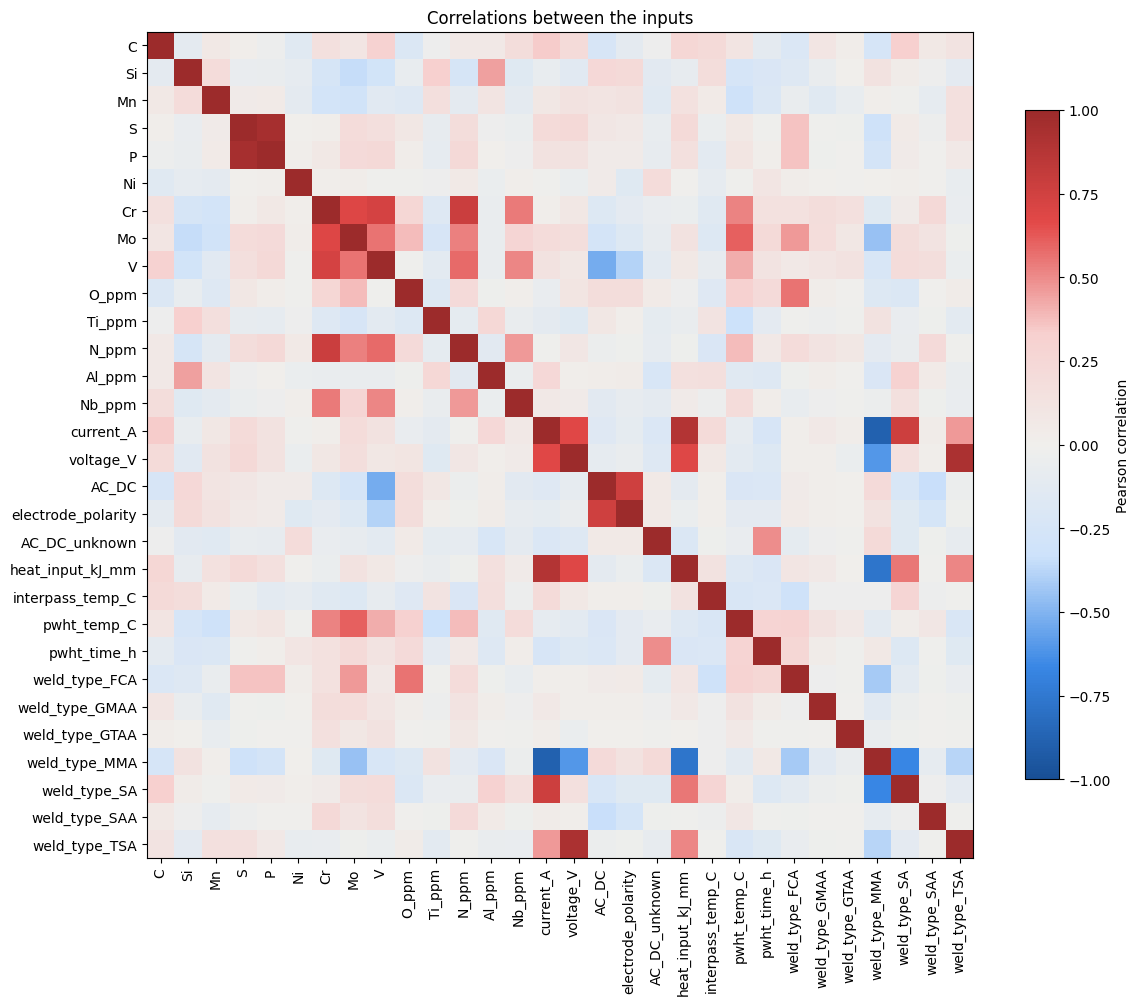

In [4]:
cmap = LinearSegmentedColormap.from_list("blue_grey_red", ["#184f95", "#3987e5", "#cde2fb", "#f0efec", "#f7d0cf", "#e34948", "#9c2b2b"])

corr = df[input_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(input_cols)), input_cols, rotation=90)
ax.set_yticks(range(len(input_cols)), input_cols)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlations between the inputs")
plt.tight_layout()
plt.show()

The colour goes from blue (-1) to red (+1) through grey (0). Most of the matrix is grey, the strong correlations sit in a few blocks:

- **Cr, Mo, V, N_ppm, Nb_ppm, pwht_temp_C:** The Cr-Mo welds, which contain these elements and are heat treated.
- **current_A, voltage_V, heat_input_kJ_mm and the `weld_type_` columns:** The welding process.
- **S, P** and **AC_DC, electrode_polarity.**

In [5]:
spearman = df[input_cols].corr(method="spearman")

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pairs = pairs[pairs.abs() > 0.6].sort_values(key=abs, ascending=False)

pd.DataFrame({
    "pearson": pairs,
    "spearman": [spearman.loc[a, b] for a, b in pairs.index],
}).round(2)

pearson  spearman
S                P                      0.95      0.61
voltage_V        weld_type_TSA          0.92      0.45
current_A        heat_input_kJ_mm       0.89      0.82
                 weld_type_MMA         -0.88     -0.89
Cr               N_ppm                  0.78      0.35
heat_input_kJ_mm weld_type_MMA         -0.77     -0.90
current_A        weld_type_SA           0.77      0.66
AC_DC            electrode_polarity     0.76      0.91
Cr               V                      0.73      0.44
                 Mo                     0.69      0.67
voltage_V        heat_input_kJ_mm       0.69      0.73
current_A        voltage_V              0.68      0.84
weld_type_MMA    weld_type_SA          -0.67     -0.67
voltage_V        weld_type_MMA         -0.61     -0.75
Mo               pwht_temp_C            0.60      0.42

Every pair above 0.6 in absolute value. Pearson measures a linear link and is sensitive to a few extreme rows. Spearman works on the ranks, so it is not. A large gap between the two means the Pearson value is driven by a few rows.

- **current_A, heat_input_kJ_mm, voltage_V, weld_type_MMA, weld_type_SA:** Strong with both methods. The heat input is computed from the current, the voltage and the travel speed, and MMA is a low current manual process while submerged arc uses high currents. These columns are partly redundant.
- **AC_DC, electrode_polarity:** Both describe the current, DC goes with a + polarity. The link is even stronger with Spearman (0.91).
- **Cr, Mo:** 0.69 with Pearson and 0.67 with Spearman, the Cr-Mo welds contain both.
- **S, P:** 0.95 with Pearson but 0.61 with Spearman. The Mart-G rows have S and P about ten times higher than the rest (see the units notebook), the next cell removes them.
- **Cr with N_ppm and V, voltage_V with weld_type_TSA:** Same pattern, the Pearson value comes from a small group of rows far from the rest (the CrMo91 welds, the tandem arc welds).

For the linear models (stepwise selection, PCA + regression), correlated inputs make the coefficients unstable, which is what the variable selection and the PCA are meant to handle. Tree-based models are not affected.

In [6]:
high_s_p = df["S"] > 0.1

print(high_s_p.sum(), df.loc[high_s_p, "weld_id"].unique())
print(df.loc[~high_s_p, ["S", "P"]].corr().round(2))

10 <StringArray>
[ 'Mart-G', 'Mart-Ga', 'Mart-Gb', 'Mart-Gc', 'Mart-Gd', 'Mart-Ge', 'Mart-Gf',
 'Mart-Gg', 'Mart-Gh', 'Mart-Gi']
Length: 10, dtype: str
      S     P
S  1.00  0.57
P  0.57  1.00


- **S, P:** The 10 rows with S above 0.1 are the Mart-G rows. Without them, the Pearson correlation between S and P drops from 0.95 to 0.57.

In [7]:
corr_target_cols = target_cols + ["reduction_area_pct", "charpy_temp_C"]

known = df[corr_target_cols].notna().astype(int)

display(df[corr_target_cols].corr().round(2))
display(known.T @ known)

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J,reduction_area_pct,charpy_temp_C
yield_strength_MPa,1.00,0.92,-0.69,-0.41,-0.48,0.35
uts_MPa,0.92,1.00,-0.74,-0.69,-0.69,0.52
elongation_pct,-0.69,-0.74,1.00,0.37,0.58,-0.55
charpy_toughness_J,-0.41,-0.69,0.37,1.00,0.85,0.47
reduction_area_pct,-0.48,-0.69,0.58,0.85,1.00,-0.65
charpy_temp_C,0.35,0.52,-0.55,0.47,-0.65,1.00


,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J,reduction_area_pct,charpy_temp_C
yield_strength_MPa,612,570,541,115,544,115
uts_MPa,570,591,533,115,536,115
elongation_pct,541,533,549,113,538,113
charpy_toughness_J,115,115,113,704,109,704
reduction_area_pct,544,536,538,109,552,109
charpy_temp_C,115,115,113,704,109,704


The first table gives the correlations, the second the number of rows behind each one: a correlation is computed on the rows where both columns are known.

- **yield_strength_MPa, uts_MPa:** 0.92, the two strength measures are nearly the same information.
- **uts_MPa, elongation_pct:** -0.74. Strength and ductility go in opposite directions, which is why `definition_bonne_soudure.md` sets a maximum on the UTS of the C-Mn welds.
- **charpy_toughness_J:** Only 115 rows have both a tensile and a Charpy result, the two tests are mostly on different rows of the same weld (see the split notebook). Its correlation with `uts_MPa` (-0.69) relies on these 115 rows only.
- **reduction_area_pct:** 0.85 with Charpy and 0.58 with elongation, it adds little on top of them, which is why it is not a target.
- **charpy_temp_C:** Correlated with the tensile targets (0.52 with UTS), although the test temperature cannot change a tensile result. Most likely because in the Evans papers the energy is fixed (28 J or 100 J) and the temperature is measured: a stronger and less tough weld reaches that energy at a higher temperature.

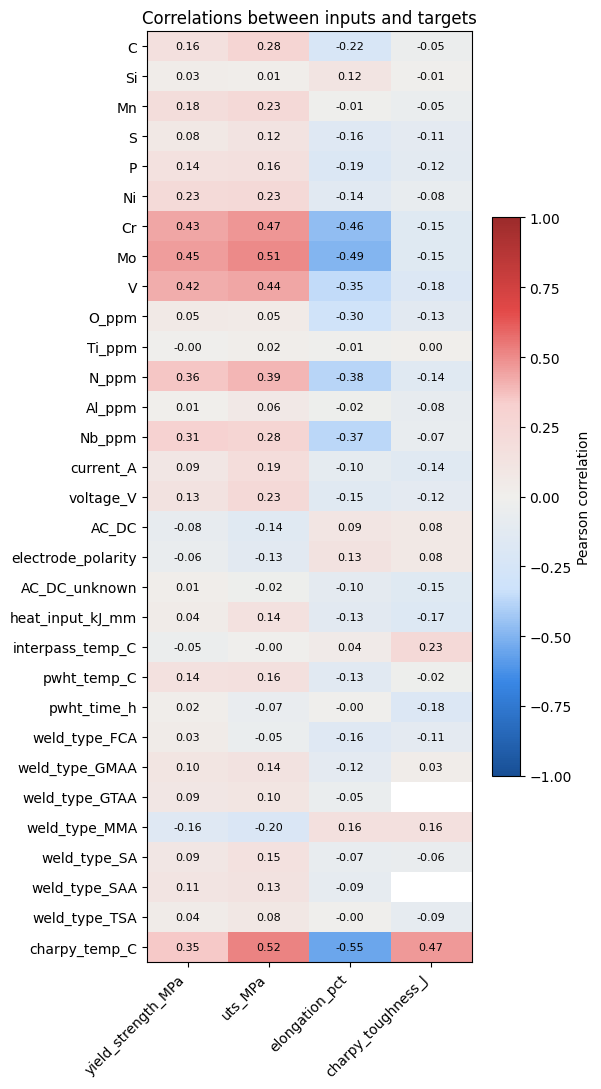

In [8]:
cols = input_cols + ["charpy_temp_C"]
corr_inputs_targets = df[cols + target_cols].corr().loc[cols, target_cols]

fig, ax = plt.subplots(figsize=(6, 11))
im = ax.imshow(corr_inputs_targets, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(target_cols)), target_cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(target_cols)):
        value = corr_inputs_targets.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(value) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.6, label="Pearson correlation")
ax.set_title("Correlations between inputs and targets")
plt.tight_layout()
plt.show()

Each cell is computed on the rows where the target is known (612 rows for `yield_strength_MPa`, 704 for `charpy_toughness_J`). The empty cells are the GTAA and SAA welds, which have no Charpy result.

- **Cr, Mo, V, N_ppm, Nb_ppm:** The strongest links with the tensile targets, positive with yield and UTS, negative with elongation. These are the elements of the Cr-Mo steels, so part of this link is the family effect: Cr-Mo welds are stronger.
- **charpy_toughness_J:** No input above 0.23 (`interpass_temp_C`). The Charpy energy depends first on the test temperature (0.47).
- **Overall:** No input explains a target alone (at most 0.51 in absolute value), the targets depend on several inputs at once, possibly in a non-linear way. A correlation close to 0 does not mean there is no link, Pearson only sees linear links.

In [9]:
df[input_cols].std().sort_values(ascending=False).round(3)

pwht_temp_C           276.977
current_A             184.404
Nb_ppm                140.729
O_ppm                 134.782
Al_ppm                100.116
Ti_ppm                 79.689
N_ppm                  75.034
interpass_temp_C       38.507
voltage_V              12.533
pwht_time_h             6.041
Cr                      1.953
heat_input_kJ_mm        1.268
Ni                      0.509
weld_type_MMA           0.460
Mo                      0.392
Mn                      0.380
weld_type_SA            0.369
AC_DC_unknown           0.307
weld_type_FCA           0.255
weld_type_TSA           0.235
electrode_polarity      0.214
AC_DC                   0.164
Si                      0.111
weld_type_GMAA          0.090
V                       0.059
weld_type_SAA           0.057
weld_type_GTAA          0.040
C                       0.024
P                       0.022
S                       0.013
dtype: float64

- **Standardisation:** The standard deviations go from 0.01 (`S`, in wt%) to 277 (`pwht_temp_C`, in °C). The PCA looks for the directions of largest variance, so without scaling it would only see `pwht_temp_C`, `current_A` and the ppm columns, because of their units. Each input is therefore centred and divided by its standard deviation (`StandardScaler`), which amounts to a PCA on the correlation matrix. The models use the same scaling, inside a `Pipeline`.
- **Columns in the PCA:** The 30 inputs only. The targets are what we want to predict and are missing on about half of the rows, they are projected afterwards as supplementary variables. `charpy_temp_C` is a test condition, missing on the rows without a Charpy result.
- **One-hot columns:** The `weld_type_` columns are kept, the welding process is a large part of the structure of the data.

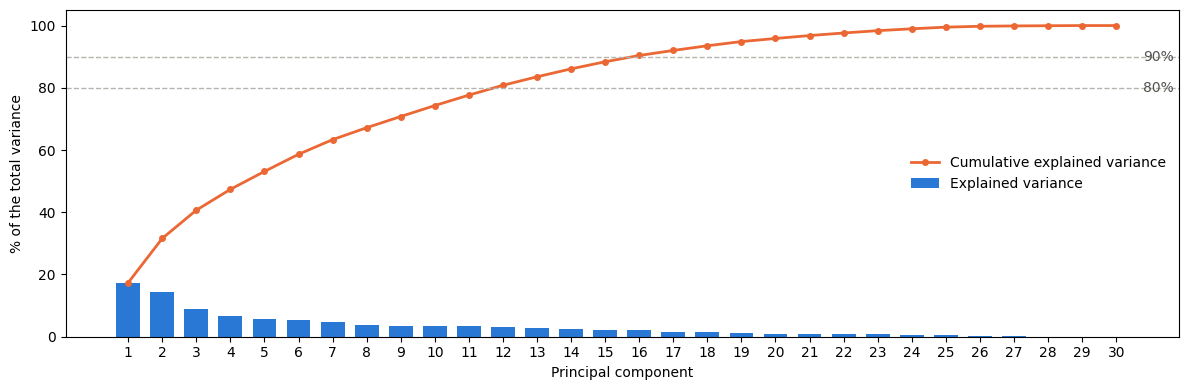

Explained by PC1 and PC2: 31.6 %
Components for 80%: 12
Components for 90%: 16
Eigenvalues above 1: 11


In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(df[input_cols])

pca = PCA()
scores = pca.fit_transform(X)
explained = pca.explained_variance_ratio_ * 100
components = np.arange(1, len(explained) + 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(components, explained, color="#2a78d6", width=0.7, label="Explained variance")
ax.plot(components, explained.cumsum(), color="#eb6834", marker="o", markersize=4, linewidth=2, label="Cumulative explained variance")
for level in [80, 90]:
    ax.axhline(level, color="#b5b4ae", linewidth=1, linestyle="--")
    ax.text(len(explained) + 0.8, level, f"{level}%", va="center", color="#52514e")
ax.set_xticks(components)
ax.set_xlabel("Principal component")
ax.set_ylabel("% of the total variance")
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.show()

print("Explained by PC1 and PC2:", explained[:2].sum().round(1), "%")
print("Components for 80%:", np.argmax(explained.cumsum() >= 80) + 1)
print("Components for 90%:", np.argmax(explained.cumsum() >= 90) + 1)
print("Eigenvalues above 1:", (pca.explained_variance_ > 1).sum())

- **Explained variance:** PC1 explains 17.4% and PC2 14.2%, so the first plane only shows 32% of the variance. The curve has no clear elbow: 12 components are needed for 80%, 16 for 90%, and 11 eigenvalues are above 1 (Kaiser criterion).
- **Why so many components:** Most chemistry columns are nearly independent from each other, and each rare column takes a component of its own. `weld_type_GMAA` (10 rows), `weld_type_GTAA` (2 rows) and `weld_type_SAA` (4 rows) are mostly carried by PC9, PC11 and PC12, each with an eigenvalue close to 1.
- **For the models:** The inputs cannot be summarised by 2 or 3 directions. A PCA + regression will need around 10 to 16 components, a number to tune by cross-validation rather than fix here.

In [11]:
pc_names = ["PC1", "PC2", "PC3", "PC4"]

loadings = pd.DataFrame(
    pca.components_[:4].T * np.sqrt(pca.explained_variance_[:4]),
    index=input_cols,
    columns=pc_names,
)

score_df = pd.DataFrame(scores[:, :4], index=df.index, columns=pc_names)
supplementary = pd.DataFrame({t: score_df.corrwith(df[t]) for t in target_cols}).T

display(loadings.sort_values("PC1").round(2))
display(supplementary.round(2))

,PC1,PC2,PC3,PC4
Mo,-0.75,-0.39,0.10,0.09
V,-0.69,-0.35,-0.35,0.17
Cr,-0.63,-0.53,-0.16,0.26
current_A,-0.63,0.71,-0.04,-0.05
heat_input_kJ_mm,-0.56,0.69,0.08,-0.11
N_ppm,-0.55,-0.46,0.04,0.27
voltage_V,-0.54,0.56,0.19,-0.33
pwht_temp_C,-0.46,-0.57,0.01,0.08
weld_type_SA,-0.45,0.47,-0.33,0.21
Nb_ppm,-0.39,-0.25,-0.30,0.24


,PC1,PC2,PC3,PC4
yield_strength_MPa,-0.37,-0.12,-0.14,0.18
uts_MPa,-0.45,-0.04,-0.19,0.18
elongation_pct,0.42,0.16,0.08,-0.12
charpy_toughness_J,0.20,0.02,-0.10,0.04


- **loadings:** The correlation between each input and each component. On standardised data, it is the component vector multiplied by the square root of its eigenvalue. The table is sorted on PC1.
- **supplementary:** The correlation between each target and the component scores, on the rows where the target is known. The targets play no part in the fit of the PCA, they are only projected on it to help read the components.

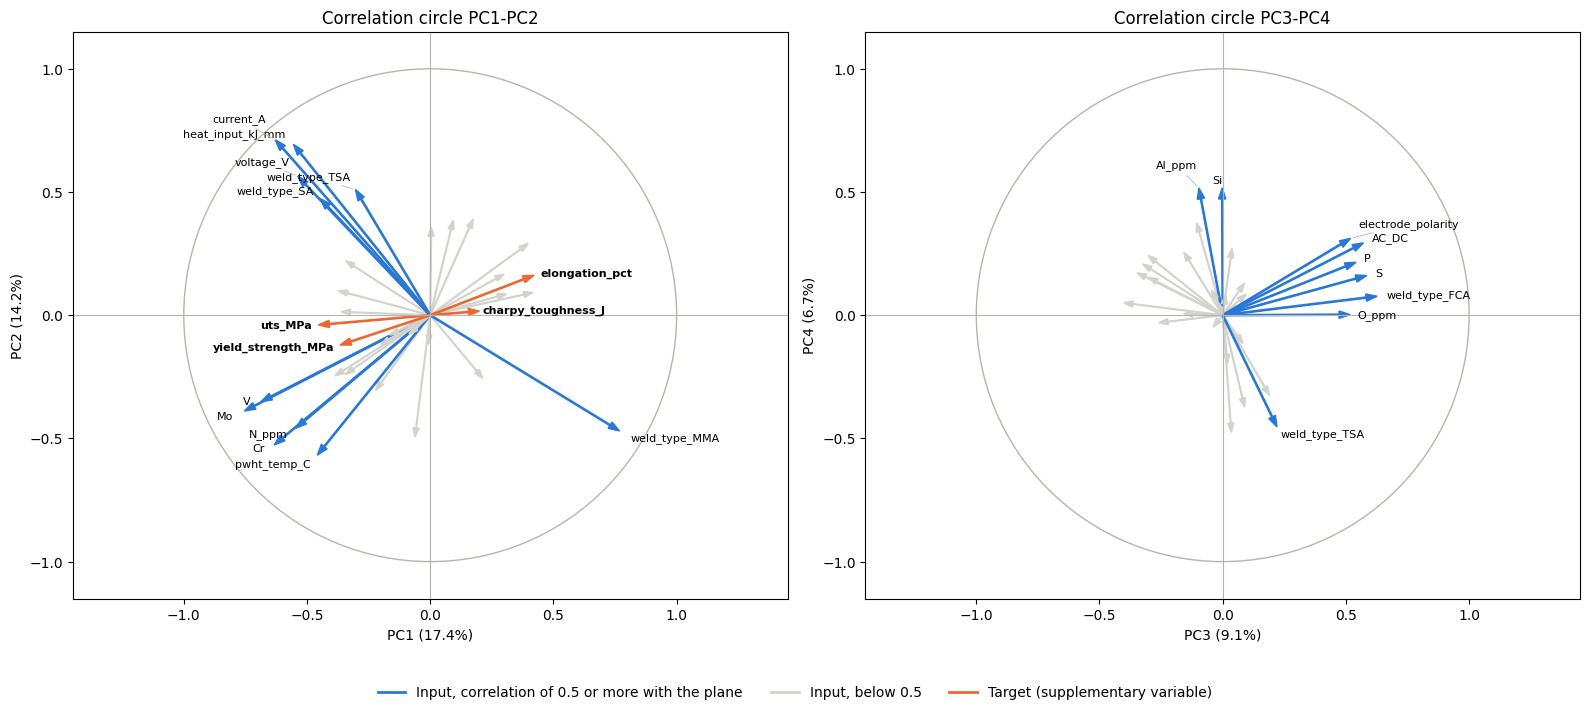

In [12]:
def correlation_circle(ax, a, b, show_targets):
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="#b5b4ae"))
    ax.axhline(0, color="#b5b4ae", linewidth=0.8)
    ax.axvline(0, color="#b5b4ae", linewidth=0.8)

    arrows = [(var, loadings.loc[var, a], loadings.loc[var, b], "#2a78d6") for var in input_cols]
    if show_targets:
        arrows += [(t, supplementary.loc[t, a], supplementary.loc[t, b], "#eb6834") for t in target_cols]

    labels = []
    for name, x, y, color in arrows:
        if name not in target_cols and np.hypot(x, y) < 0.5:
            ax.arrow(0, 0, x, y, color="#d3d2cc", width=0.003, head_width=0.025, length_includes_head=True)
            continue
        ax.arrow(0, 0, x, y, color=color, width=0.005, head_width=0.03, length_includes_head=True)
        labels.append([name, x, y, x * 1.06, y * 1.06])

    labels.sort(key=lambda label: label[4])
    for i, label in enumerate(labels):
        for other in labels[:i]:
            same_side = (label[1] >= 0) == (other[1] >= 0)
            if same_side and abs(label[3] - other[3]) < 0.35 and label[4] - other[4] < 0.06:
                label[4] = other[4] + 0.06

    for name, x, y, tx, ty in labels:
        ax.annotate(name, xy=(x, y), xytext=(tx, ty), fontsize=8, ha="left" if x >= 0 else "right", va="center",
                    fontweight="bold" if name in target_cols else "normal",
                    arrowprops=dict(arrowstyle="-", color="#b5b4ae", linewidth=0.6) if abs(ty - y * 1.06) > 0.02 else None)

    ia, ib = pc_names.index(a), pc_names.index(b)
    ax.set_xlabel(f"{a} ({explained[ia]:.1f}%)")
    ax.set_ylabel(f"{b} ({explained[ib]:.1f}%)")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.set_title(f"Correlation circle {a}-{b}")


fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
correlation_circle(axes[0], "PC1", "PC2", show_targets=True)
correlation_circle(axes[1], "PC3", "PC4", show_targets=False)

handles = [
    Line2D([], [], color="#2a78d6", linewidth=2, label="Input, correlation of 0.5 or more with the plane"),
    Line2D([], [], color="#d3d2cc", linewidth=2, label="Input, below 0.5"),
    Line2D([], [], color="#eb6834", linewidth=2, label="Target (supplementary variable)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

An arrow close to the circle is well represented by the plane, and two arrows pointing the same way are positively correlated. Only the inputs with a correlation of 0.5 or more with the plane are labelled. The targets are only drawn on the first plane: their correlations with PC3 and PC4 stay below 0.2.

- **PC1 (17.4%):** MMA (0.77), Si and the AC current on the right, against the alloying elements (Mo -0.75, V -0.69, Cr -0.63, N_ppm -0.55) and the high current processes (current_A -0.63, heat_input_kJ_mm -0.56) on the left. It separates the standard MMA electrodes from the rest.
- **PC2 (14.2%):** The welding energy at the top (current_A 0.71, heat_input_kJ_mm 0.69, voltage_V 0.56, SA and TSA), against Cr and the post-weld heat treatment at the bottom (pwht_temp_C -0.57, pwht_time_h -0.49). It separates the submerged arc welds from the heat treated Cr-Mo welds.
- **PC3 (9.1%):** The impurities (S 0.58, P 0.54, O_ppm 0.52) with the FCA process (0.63) and the current type (AC_DC 0.57, electrode_polarity 0.52).
- **PC4 (6.7%):** Si and Al_ppm (0.52 each) against TSA (-0.45) and AC_DC_unknown (-0.48).
- **Targets:** UTS and yield point to the left of PC1 (-0.45 and -0.37), on the side of the alloying elements, and elongation points the other way (0.42): the same strength/ductility trade-off as in the correlations. Charpy is poorly represented (0.20 on PC1, below 0.1 on the other components): the main directions of the inputs say little about toughness.

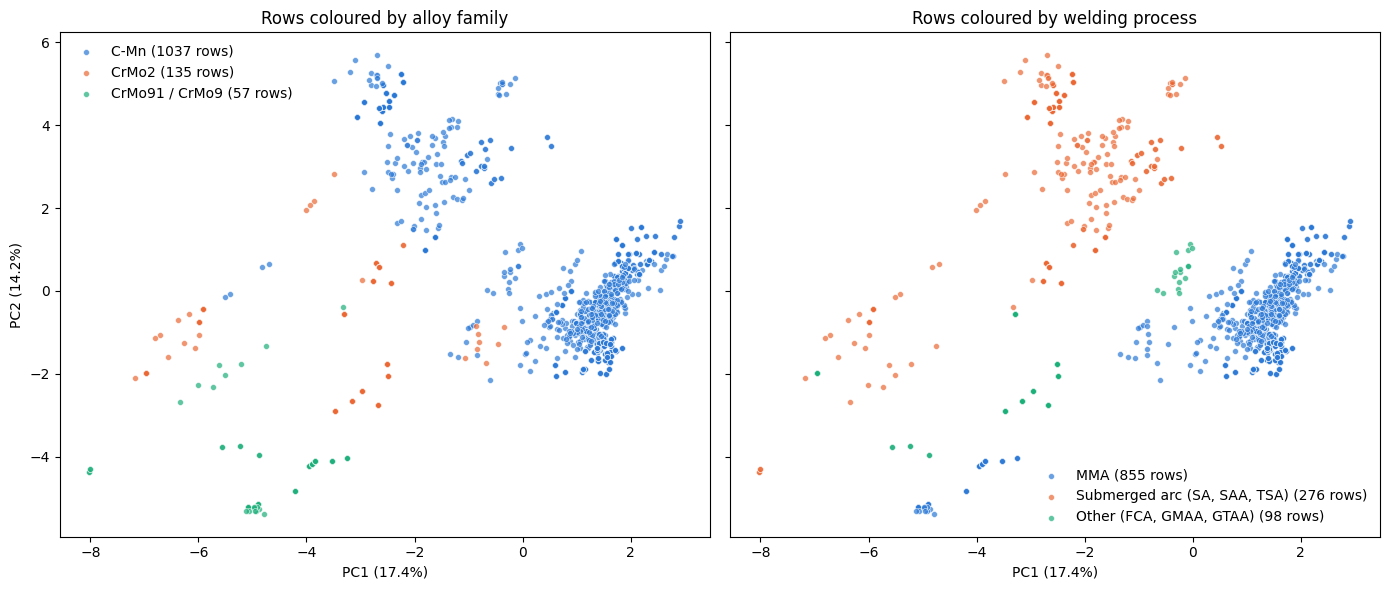

In [13]:
process = pd.Series("Other (FCA, GMAA, GTAA)", index=df.index)
process[df["weld_type_MMA"] == 1] = "MMA"
process[df[["weld_type_SA", "weld_type_SAA", "weld_type_TSA"]].sum(axis=1) == 1] = "Submerged arc (SA, SAA, TSA)"

family = df["family"].replace({"CrMo91": "CrMo91 / CrMo9", "CrMo9": "CrMo91 / CrMo9"})

colors = ["#2a78d6", "#eb6834", "#1baf7a"]
panels = [
    (family, ["C-Mn", "CrMo2", "CrMo91 / CrMo9"], "Rows coloured by alloy family"),
    (process, ["MMA", "Submerged arc (SA, SAA, TSA)", "Other (FCA, GMAA, GTAA)"], "Rows coloured by welding process"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, (labels, order, title) in zip(axes, panels):
    for color, label in zip(colors, order):
        mask = (labels == label).values
        ax.scatter(scores[mask, 0], scores[mask, 1], s=18, color=color, alpha=0.7, edgecolor="white", linewidth=0.5, label=f"{label} ({mask.sum()} rows)")
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}%)")
    ax.set_title(title)
    ax.legend(frameon=False)
axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}%)")
plt.tight_layout()
plt.show()

The single CrMo9 row is drawn with the CrMo91 rows, both are 9Cr-1Mo steels.

- **Alloy family:** The Cr-Mo welds sit on the left of PC1, mostly at the bottom of PC2, apart from most C-Mn welds. The families of `definition_bonne_soudure.md` are a real structure of the inputs, not only a difference of thresholds. The metrics are therefore given per family, and the cross-validation folds of `modeling/utils.py` are stratified on it.
- **Welding process:** The C-Mn welds form two clouds, the MMA welds on the right and the submerged arc welds at the top (high heat input).
- **Clustering:** These clouds are what a clustering (K-means, Gaussian mixture, hierarchical clustering) should find again in the semi-supervised step.